# Divar Real Estate Analysis — Recommender System (Clustering)

**Problem 1:** Clustering properties to support a property recommender system

**Author:** Mahdi Tarrah

**Data:** `data/Divar.csv`

## Data Preparation

In [33]:
#libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import utm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator

In [34]:
clustering_columns = ['price_value','building_size','rooms_count','location_latitude','location_longitude','cat2_slug','cat3_slug','city_slug','construction_year', 'has_parking', 'has_elevator']
df = pd.read_csv('../data/Divar.csv', usecols=clustering_columns)
print(df.shape)
df.head()

(1000000, 11)


,cat2_slug,cat3_slug,city_slug,price_value,building_size,rooms_count,has_elevator,has_parking,construction_year,location_latitude,location_longitude
0,temporary-rent,villa,karaj,NaN,500.0,سه,NaN,NaN,NaN,35.811684,50.936600
1,residential-sell,apartment-sell,tehran,8.500000e+09,60.0,یک,True,True,۱۳۸۴,NaN,NaN
2,residential-rent,apartment-rent,tehran,NaN,132.0,سه,True,True,۱۴۰۱,35.703865,51.373459
3,commercial-rent,office-rent,tehran,NaN,90.0,یک,True,True,۱۴۰۰,NaN,NaN
4,residential-sell,apartment-sell,mashhad,5.750000e+09,115.0,دو,True,True,۱۴۰۳,NaN,NaN


In [35]:
#filled
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   cat2_slug           1000000 non-null  str    
 1   cat3_slug           999999 non-null   str    
 2   city_slug           999998 non-null   str    
 3   price_value         568346 non-null   float64
 4   building_size       980394 non-null   float64
 5   rooms_count         845899 non-null   str    
 6   has_elevator        541749 non-null   object 
 7   has_parking         728156 non-null   object 
 8   construction_year   815828 non-null   str    
 9   location_latitude   655608 non-null   float64
 10  location_longitude  655608 non-null   float64
dtypes: float64(4), object(2), str(5)
memory usage: 83.9+ MB


In [36]:
#copy
data = df.copy()

#clean
data.loc[data['price_value'] <= 0, 'price_value'] = np.nan

def clean_outliers(data,column):
    """Set outliers to the NaN."""
    logs = np.log(data[column])
    q1, q3 = logs.quantile(0.25),logs.quantile(0.75)
    iqr = q3 - q1
    data.loc[~logs.between(q1 - 1.5 * iqr,q3 + 1.5 * iqr), column] = np.nan
    return data

data = clean_outliers(data,'price_value')
data = clean_outliers(data,'building_size')

inside_iran = (data['location_latitude'].between(25,40)) & (data['location_longitude'].between(44,63.5))
data.loc[~inside_iran,['location_latitude','location_longitude']] = np.nan

data = data.dropna(subset=['building_size','price_value','location_latitude','location_longitude'])
print(data.shape)
print(data[['price_value','building_size']].describe())

(324485, 11)
        price_value  building_size
count  3.244850e+05  324485.000000
mean   5.047053e+09     130.622852
std    6.172471e+09      87.705984
min    1.640000e+08      23.000000
25%    1.600000e+09      75.000000
50%    3.000000e+09     100.000000
75%    5.850000e+09     153.000000
max    5.100000e+10     538.000000


In [37]:
xy = [utm.from_latlon(lat, lon, force_zone_number=39)[:2] for lat, lon in zip(data['location_latitude'], data['location_longitude'])]

data['utm_x'] = [p[0] for p in xy]
data['utm_y'] = [p[1] for p in xy]

print(data[['utm_x','utm_y']].describe())

              utm_x         utm_y
count  3.244850e+05  3.244850e+05
mean   5.549497e+05  3.888984e+06
std    2.790465e+05  2.525020e+05
min   -1.146343e+05  2.803746e+06
25%    4.763461e+05  3.860848e+06
50%    5.304762e+05  3.953651e+06
75%    5.738981e+05  4.042502e+06
max    1.660176e+06  4.407134e+06


In [38]:
#cheak errors
print(((data['utm_x'] < 100000) | (data['utm_x'] > 900000)).sum())

51619


In [39]:
#rooms
rooms_mapping = {'بدون اتاق':0,'یک':1,'دو':2,'سه':3,'چهار':4,'پنج یا بیشتر':5}
data['rooms_count'] = data['rooms_count'].map(rooms_mapping)

## Part 1 — Feature Selection and KMeans with 10 Clusters

### Choosing the feature set

In [40]:
print(data[['construction_year','has_parking','has_elevator']].info())
print(data['construction_year'].value_counts(dropna=False).head(10))

<class 'pandas.DataFrame'>
Index: 324485 entries, 7 to 999995
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   construction_year  275148 non-null  str   
 1   has_parking        266716 non-null  object
 2   has_elevator       200577 non-null  object
dtypes: object(2), str(1)
memory usage: 9.9+ MB
None
construction_year
۱۴۰۳    50587
NaN     49337
۱۴۰۲    22978
۱۴۰۰    15228
۱۳۹۰    14977
۱۳۹۵    14602
۱۴۰۱    12499
۱۳۹۷    11304
۱۳۹۸    11174
۱۳۹۶    11151
Name: count, dtype: int64


In [41]:
#convert to number
digits = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')
year = data['construction_year'].replace('قبل از ۱۳۷۰', '۱۳۶۹')
data['construction_year'] = pd.to_numeric(year.str.translate(digits), errors='coerce')
print(data['construction_year'].describe())

count    275148.000000
mean       1394.260892
std           8.411427
min        1369.000000
25%        1390.000000
50%        1396.000000
75%        1402.000000
max        1403.000000
Name: construction_year, dtype: float64


In [42]:
data_cmp = data.dropna(subset=['rooms_count','construction_year'])
print(data.shape, data_cmp.shape)

(324485, 13) (275143, 13)


In [43]:
print(data_cmp[['price_value','building_size','rooms_count','construction_year']].corr())

                   price_value  building_size  rooms_count  construction_year
price_value           1.000000       0.398886     0.344050          -0.026310
building_size         0.398886       1.000000     0.617901           0.090851
rooms_count           0.344050       0.617901     1.000000           0.116831
construction_year    -0.026310       0.090851     0.116831           1.000000


In [44]:
feature_sets = {'A: price + utm + size': ['price_value','utm_x','utm_y','building_size'],'B: A + rooms':['price_value','utm_x','utm_y','building_size','rooms_count'],'C: price + utm':['price_value','utm_x','utm_y'],'D: C + year': ['price_value','utm_x','utm_y','construction_year']}

for name, feats in feature_sets.items():
    X = StandardScaler().fit_transform(data_cmp[feats])
    km = KMeans(10, random_state=44)
    labels = km.fit_predict(X)
    print(name)
    print(silhouette_score(X, labels, sample_size=10000, random_state=44))
    print(calinski_harabasz_score(X, labels))
    print(davies_bouldin_score(X, labels))

A: price + utm + size
0.38103529189277213
102768.06431253256
1.0292128341314926
B: A + rooms
0.34443408378687007
74908.88484914752
1.0877651052155721
C: price + utm
0.4757394657372042
186268.2007138129
0.75140171115489
D: C + year
0.329410603147055
94459.92883366671
0.9917509071346811


<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
چهار ترکیب ویژگی رو با سه معیار سنجیدم و روی ردیف‌هایی که همه ستون‌ها رو داشتن تا مقایسه منصفانه باشه
<br>
هر سه معیار گفتن بهترین ترکیب قیمت و مختصاته و هرچی ویژگی اضافه کردم خوشه‌ها بدتر شدن
<br>
تعداد اتاق رو نذاشتم چون تقریبا همون حرف زیربنا رو میزنه و سال ساختم چون رابطه‌ای با قیمت نداشت
<br>
بقیه ستون‌ها هم یا مال خود آگهین نه ملک یا فقط برای اجاره پر میشن یا برای همه یکسانن
</font></p>

### KMeans with 10 clusters

In [45]:
#final clustering
scaler = StandardScaler()
X = scaler.fit_transform(data[['price_value','utm_x','utm_y']])

km = KMeans(10, random_state=44)
data['cluster'] = km.fit_predict(X)

print(data['cluster'].value_counts().sort_index())

cluster
0    137901
1     15432
2     14367
3     24922
4     29346
5     24057
6     10223
7     20049
8     42856
9      5332
Name: count, dtype: int64


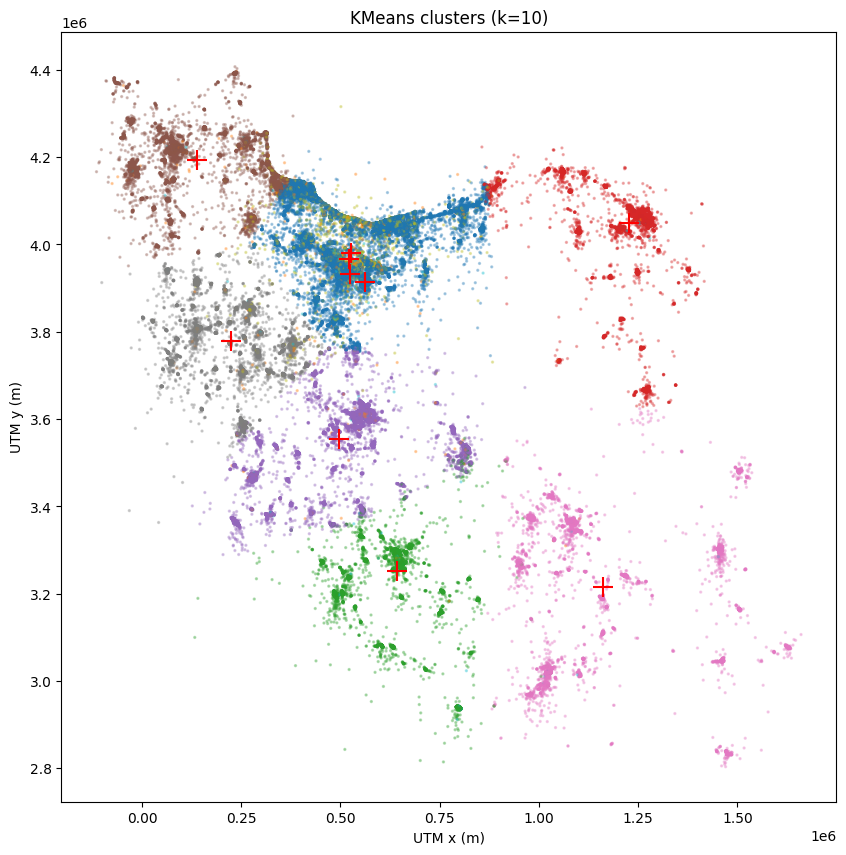

In [46]:
#map
centers = scaler.inverse_transform(km.cluster_centers_)

plt.figure(figsize=(10, 10))
plt.scatter(data['utm_x'], data['utm_y'], c=data['cluster'], s=2, alpha=0.3, cmap='tab10')
plt.scatter(centers[:, 1], centers[:, 2], marker='+', c='red', s=200)
plt.xlabel('UTM x (m)')
plt.ylabel('UTM y (m)')
plt.title('KMeans clusters (k=10)')
plt.show()

In [47]:
profile = data.groupby('cluster').agg(n=('cluster','size'),price_M=('price_value', lambda s: round(s.median()/1e6)),size_m2=('building_size','median'))
profile['top_cities'] = data.groupby('cluster')['city_slug'].apply(lambda s: ', '.join(s.value_counts().head(3).index))
print(profile.sort_values('price_M'))

              n  price_M  size_m2                        top_cities
cluster                                                            
6         10223     2190    145.0     kerman, bandar-abbas, zahedan
0        137901     2300     85.0  tehran, karaj, andisheh-new-town
7         20049     2450    110.0         kermanshah, hamedan, arak
5         24057     2500    110.0            tabriz, urmia, ardabil
3         24922     2600    108.0       mashhad, neyshabur, bojnurd
4         29346     2800    120.0              isfahan, ahvaz, yazd
2         14367     3700    130.0            shiraz, sadra, bushehr
8         42856     8000    107.0              tehran, karaj, rasht
1         15432    18360    145.0            tehran, isfahan, karaj
9          5332    35200    195.0          tehran, mashhad, isfahan


<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
مراکز خوشه رو به متر برگردوندم وگرنه رو نقشه سر جاشون نمی‌افتادن
<br>
هر شهر دور از تهران خوشه خودشو داره ولی تهران به چهار خوشه قیمتی شکسته از ۲.۳ تا ۳۵ میلیارد یعنی اونجا که همه آگهی‌ها یه جان قیمت تعیین‌کننده شده
<br>
همینم منطق توصیه‌گره چون کسی که دنبال ملک دو میلیاردیه نباید آپارتمان سی و پنج میلیاردی ببینه
<br>
مختصات رو همه با یه زون ثابت حساب کردم تا با هم قابل مقایسه بمونن
</font></p>

## Part 2 — Choosing the Number of Clusters

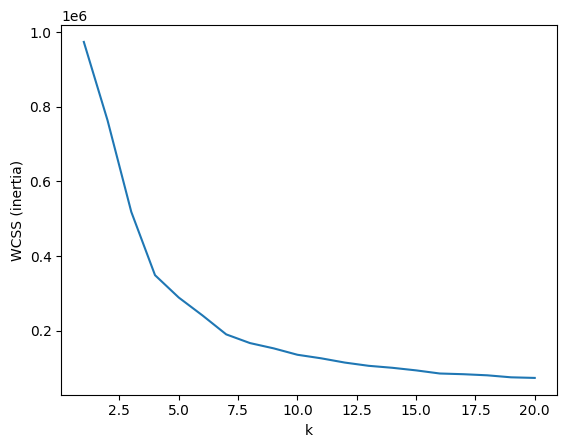

In [48]:
res = []
for k in range(1, 21):
    km = KMeans(k, random_state=44)
    km.fit(X)
    res.append(km.inertia_)

plt.plot(range(1, 21), res)
plt.xlabel('k')
plt.ylabel('WCSS (inertia)')
plt.show()

<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
نمودار آرنج رو برای k از ۱ تا ۲۰ کشیدم و چون زانوش با چشم معلوم نبود با KneeLocator حسابش کردم که ۷ داد
</font></p>

In [49]:
loc = KneeLocator(range(1, 21), res, curve='convex', direction='decreasing')
print(loc.elbow, loc.knee)

7 7


In [50]:
sil, cal, dav = [], [], []

for k in range(2, 21):
    km = KMeans(k, random_state=44)
    labels = km.fit_predict(X)
    sil.append( silhouette_score(X, labels, sample_size=10000, random_state=44))
    cal.append(calinski_harabasz_score(X, labels))
    dav.append(davies_bouldin_score(X, labels))

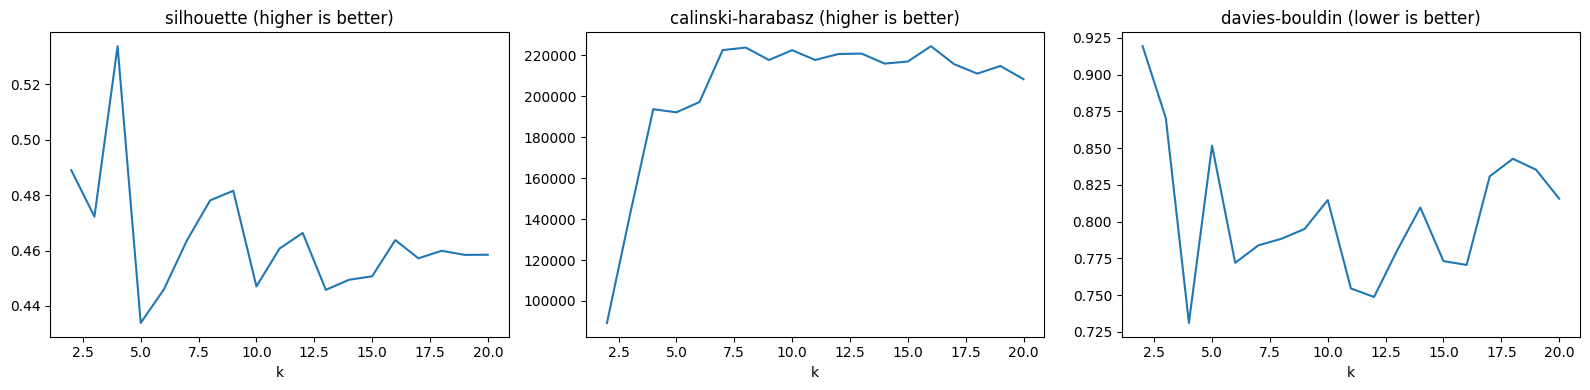

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(range(2, 21), sil)
axes[0].set_title('silhouette (higher is better)')

axes[1].plot(range(2, 21), cal)
axes[1].set_title('calinski-harabasz (higher is better)')

axes[2].plot(range(2, 21), dav)
axes[2].set_title('davies-bouldin (lower is better)')

for ax in axes:
    ax.set_xlabel('k')

plt.tight_layout()
plt.show()

<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
سه معیار دیگه رو هم تو یه حلقه حساب کردم تا KMeans یه بار اجرا شه
<br>
سیلوئت و دیویس k=۴ رو بهتر نشون دادن ولی کالینسکی مثل آرنج از ۷ به بعد تخت میشه
<br>
سیلوئت رو نمونه ده هزارتایی حساب شده و نمودارش دندونه‌داره پس کمتر میشه بهش تکیه کرد ولی آرنج و کالینسکی رو کل دادن و صافن
</font></p>

In [52]:
#compare k=4 and k=7
for k in [4, 7]:
    km_test = KMeans(k, random_state=44)
    labels_test = km_test.fit_predict(X)

    tmp = data.copy()
    tmp['c'] = labels_test

    prof = tmp.groupby('c').agg(n=('c', 'size'),price_M=('price_value',lambda s: round(s.median() / 1e6)),size_m2=('building_size','median'))
    prof['top_cities'] = tmp.groupby('c')['city_slug'].apply(lambda s: ','.join(s.value_counts().head(3).index))

    print(f'k = {k}')
    print(prof.sort_values('price_M'))
    print()

k = 4
        n  price_M  size_m2                      top_cities
c                                                          
0   26385     2500    110.0       mashhad,neyshabur,bojnurd
3  222405     2800     92.0  tehran,karaj,andisheh-new-town
2   54348     2900    125.0            isfahan,shiraz,ahvaz
1   21347    20700    155.0            tehran,isfahan,karaj

k = 7
        n  price_M  size_m2                      top_cities
c                                                          
6   11564     2300    138.0     kerman,bandar-abbas,zahedan
5   46039     2500    109.0         tabriz,rasht,kermanshah
0  151455     2550     85.0  tehran,karaj,andisheh-new-town
4   25232     2600    108.0       mashhad,neyshabur,bojnurd
2   45765     2960    123.0            isfahan,shiraz,ahvaz
3   35300    12000    120.0            tehran,karaj,isfahan
1    9130    30000    180.0          tehran,mashhad,isfahan



<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
برای تصمیم بین ۴ و ۷ پروفایل هر دو رو دیدم
<br>
با ۴ خوشه دو سوم داده تو یه خوشه می‌افته و فقط دو سطح قیمتی داریم که برای توصیه‌گر فایده نداره
<br>
با ۷ خوشه تهران سه سطح قیمتی داره و شهرای دیگه هم جدا میشن مثل کرمان و بندرعباس یا تبریز و رشت
<br>
پس ۷ رو انتخاب کردم
</font></p>

In [56]:
#final model with k=7
km_final = KMeans(7, random_state=44)
data['cluster_final'] = km_final.fit_predict(X)

centers_final = scaler.inverse_transform(km_final.cluster_centers_)

print(data['cluster_final'].value_counts().sort_index())

cluster_final
0    151455
1      9130
2     45765
3     35300
4     25232
5     46039
6     11564
Name: count, dtype: int64


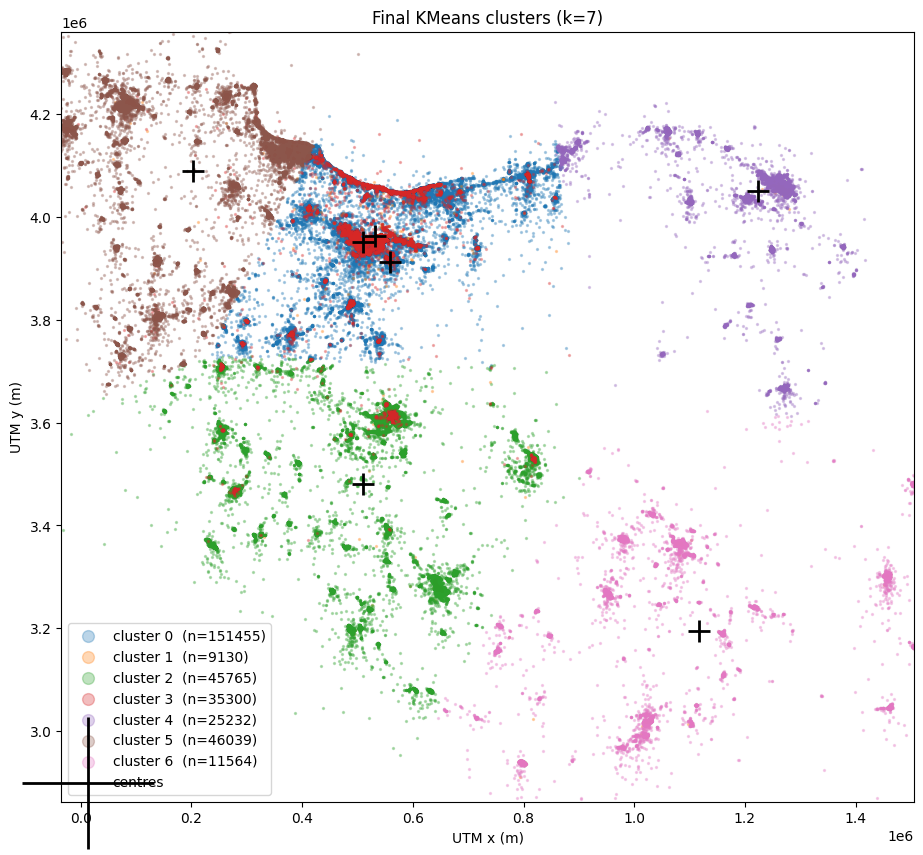

In [59]:
plt.figure(figsize=(11, 10))

for c in sorted(data['cluster_final'].unique()):
    sub = data[data['cluster_final'] == c]
    plt.scatter(sub['utm_x'], sub['utm_y'], s=2, alpha=0.3, label=f'cluster {c}  (n={len(sub)})')

x_lo, x_hi = data['utm_x'].quantile([0.001, 0.999])
y_lo, y_hi = data['utm_y'].quantile([0.001, 0.999])

inside = ((centers_final[:, 1] >= x_lo) & (centers_final[:, 1] <= x_hi) & (centers_final[:, 2] >= y_lo) & (centers_final[:, 2] <= y_hi))

plt.scatter(centers_final[inside, 1], centers_final[inside, 2],marker='+', c='black', s=250, linewidths=2, label='centres')
plt.xlim(x_lo, x_hi)
plt.ylim(y_lo, y_hi)
plt.xlabel('UTM x (m)')
plt.ylabel('UTM y (m)')
plt.title('Final KMeans clusters (k=7)')
plt.legend(markerscale=6)
plt.show()